Visualizing initial weights of GD

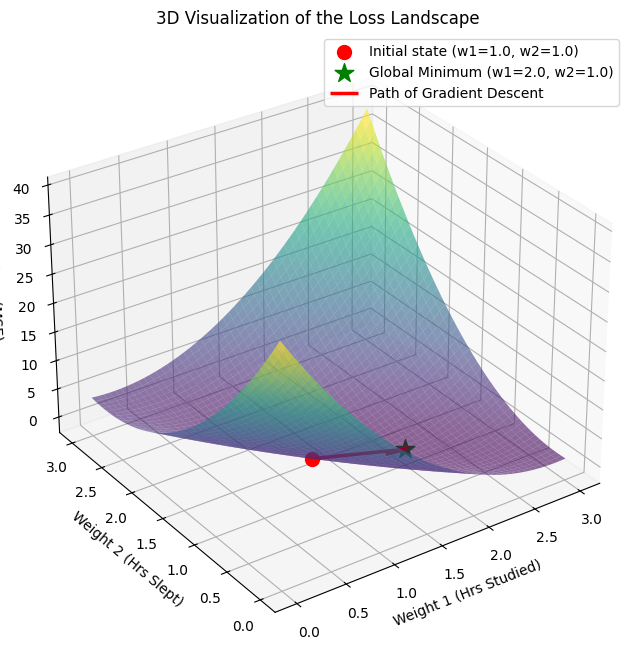

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2]
])
y = np.array([4, 5, 7, 8])

def mse_loss(w1, w2):
    total_loss = np.zeros_like(w1)
    for i in range(len(y)):
        y_pred = w1 * X[i, 0] + w2 * X[i, 1]
        total_loss += (y[i] - y_pred)**2
    return total_loss / len(y)

w1_vals = np.linspace(0, 3, 50)
w2_vals = np.linspace(0, 3, 50)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = mse_loss(W1, W2)

w1_init, w2_init = 1.0, 1.0
loss_init = mse_loss(w1_init, w2_init)

w1_min, w2_min = 2.0, 1.0
loss_min = mse_loss(w1_min, w2_min)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6, edgecolor='none')

ax.scatter([w1_init], [w2_init], [loss_init],
           color='red', s=100, label=f'Initial state (w1={w1_init}, w2={w2_init})', zorder=5)

ax.scatter([w1_min], [w2_min], [loss_min],
           color='green', s=200, marker='*', label=f'Global Minimum (w1={w1_min}, w2={w2_min})', zorder=5)

ax.quiver(w1_init, w2_init, loss_init,
          w1_min - w1_init, w2_min - w2_init, loss_min - loss_init,
          color='red', arrow_length_ratio=0.1, linewidth=2.5, label='Path of Gradient Descent')

ax.set_xlabel('Weight 1 (Hrs Studied)')
ax.set_ylabel('Weight 2 (Hrs Slept)')
ax.set_zlabel('Loss (MSE)')
ax.set_title('3D Visualization of the Loss Landscape')
ax.view_init(elev=30, azim=-125)
ax.legend()

plt.show()

# Mini Batch Gradient Descent Example
## Edit the following code with given question

In [3]:
import numpy as np

X = np.array([
    [1, 2],
    [2, 1],
    [2, 3],
    [3, 2]
])

y = np.array([4, 5, 7, 8])

weights = np.array([1.0, 1.0])
learning_rate = 0.1
batch_size = 2

print("Initial Weights:", weights, "\n")

total_rows = len(y)

for i in range(0, total_rows, batch_size):
    X_batch = X[i : i + batch_size]
    y_batch = y[i : i + batch_size]


    predictions = np.dot(X_batch, weights)

    errors = predictions - y_batch

    gradients = (1 / len(X_batch)) * np.dot(X_batch.T, errors)

    weights = weights - (learning_rate * gradients)

    print(f"--- Processing Batch (Rows {i+1} to {i+len(X_batch)}) ---")
    print(f"Gradients: {gradients}")
    print(f"Updated Weights: {weights}\n")

print("Final Weights after 1 Epoch:", weights)

Initial Weights: [1. 1.] 

--- Processing Batch (Rows 1 to 2) ---
Gradients: [-2.5 -2. ]
Updated Weights: [1.25 1.2 ]

--- Processing Batch (Rows 3 to 4) ---
Gradients: [-3.675 -3.2  ]
Updated Weights: [1.6175 1.52  ]

Final Weights after 1 Epoch: [1.6175 1.52  ]


# Prediction on new dataset


In [5]:
def predict_sale(time_on_site, pages_visited, returning_user, w1, w2, w3):
    prediction = (w1 * time_on_site) + (w2 * pages_visited) + (w3 * returning_user)
    return prediction

print("\n--- Predict a New Customer's Outcome ---")
print("Students: Enter the final weights you calculated from your training loop!")

final_w1 = 0.5
final_w2 = 1.2
final_w3 = 2.0      #Fill it yourself

new_customer_time = 10        # minutes spent
new_customer_pages = 5        # pages visited
new_customer_returning = 1    # 1 = returning, 0 = new


predicted_prob = predict_sale(
    new_customer_time,
    new_customer_pages,
    new_customer_returning,
    final_w1,
    final_w2,
    final_w3
)

print(f"Customer Profile -> Time: {new_customer_time}m | Pages: {new_customer_pages} | Returning: {new_customer_returning}")
print(f"Predicted Probability of Sale: {predicted_prob:.2f}%")


--- Predict a New Customer's Outcome ---
Students: Enter the final weights you calculated from your training loop!
Customer Profile -> Time: 10m | Pages: 5 | Returning: 1
Predicted Probability of Sale: 13.00%


#Gradient Descent for Classification

In [6]:

X = np.array([
    [25, 0.5, 15, 1], [35, 1.2, 25, 2], [45, 2.5, 10, 3], [22, 0.3, 5,  0],
    [50, 3.0, 30, 4], [28, 0.8, 12, 1], [32, 1.5, 20, 2], [40, 2.0, 18, 2],
    [60, 4.0, 5,  1], [29, 0.9, 22, 1], [38, 1.8, 15, 3], [55, 3.5, 25, 3],
    [24, 0.4, 8,  1], [31, 1.1, 16, 2], [42, 2.2, 12, 2], [36, 1.6, 28, 1],
    [48, 2.8, 14, 3], [27, 0.6, 10, 1], [33, 1.3, 24, 2], [52, 3.2, 20, 3]
])

y = np.array([0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1])

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_scaled = (X - mu) / sigma

weights = np.array([0.0, 0.0, 0.0, 0.0])
learning_rate = 0.1
epochs = 10
m = len(y)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

print("Starting Training...\n")

for epoch in range(epochs):
    z = np.dot(X_scaled, weights)
    y_pred = sigmoid(z)

    error = y_pred - y

    loss = -np.mean(y * np.log(y_pred + 1e-9) + (1 - y) * np.log(1 - y_pred + 1e-9))

    gradients = (1 / m) * np.dot(X_scaled.T, error)

    weights = weights - (learning_rate * gradients)


    print(f"Epoch {epoch} | Log Loss: {loss:.4f}")

print("\nTraining Complete!")
print("Final Optimized Weights:", np.round(weights, 4))

Starting Training...

Epoch 0 | Log Loss: 0.6931
Epoch 1 | Log Loss: 0.6465
Epoch 2 | Log Loss: 0.6055
Epoch 3 | Log Loss: 0.5694
Epoch 4 | Log Loss: 0.5376
Epoch 5 | Log Loss: 0.5094
Epoch 6 | Log Loss: 0.4842
Epoch 7 | Log Loss: 0.4617
Epoch 8 | Log Loss: 0.4415
Epoch 9 | Log Loss: 0.4233

Training Complete!
Final Optimized Weights: [ 0.3271  0.3279 -0.0347  0.2658]


Prediction on new variable [34, 1.4, 18, 2]

In [7]:
print("\n--- Predicting for a New Customer ---")

new_customer = np.array([34, 1.4, 18, 2])

new_customer_scaled = (new_customer - mu) / sigma

z_new = np.dot(new_customer_scaled, weights)

probability = sigmoid(z_new)

print(f"Customer Profile: Age {new_customer[0]} | Income {new_customer[1]}L | Commute {new_customer[2]}km | Visits {new_customer[3]}")
print(f"Raw z-value: {z_new:.4f}")
print(f"Predicted Probability of Buying EV: {probability * 100:.2f}%")

if probability >= 0.5:
    print("Final Classification: 1 (Will Buy)")
else:
    print("Final Classification: 0 (Will Not Buy)")


--- Predicting for a New Customer ---
Customer Profile: Age 34.0 | Income 1.4L | Commute 18.0km | Visits 2.0
Raw z-value: -0.1984
Predicted Probability of Buying EV: 45.06%
Final Classification: 0 (Will Not Buy)


np.array([
    [25, 5, 15, 2, 1],
    [32, 12, 20, 3, 2],
    [45, 25, 10, 4, 3],
    [22, 3, 5, 1, 0],
    [50, 30, 30, 5, 4],
    [28, 8, 12, 2, 1],
    [35, 15, 18, 3, 2],
    [40, 20, 22, 4, 2],
    [60, 40, 5, 2, 1],
    [29, 9, 25, 2, 1],
    [38, 18, 15, 3, 3],
    [55, 35, 28, 5, 3],
    [24, 4, 8, 1, 1],
    [31, 11, 16, 2, 2],
    [42, 22, 12, 4, 2],
    [36, 16, 26, 3, 1],
    [48, 28, 14, 4, 3],
    [27, 6, 10, 2, 1],
    [33, 13, 24, 3, 2],
    [52, 32, 20, 5, 3],
    [26, 7, 18, 2, 1],
    [41, 21, 22, 4, 2],
    [30, 10, 14, 3, 2],
    [47, 27, 16, 4, 3],
    [34, 14, 19, 3, 2]
])

y = np.array([
    0, 1, 1, 0, 1,
    0, 1, 1, 1, 0,
    1, 1, 0, 0, 1,
    1, 1, 0, 1, 1,
    0, 1, 0, 1, 1
])

Use this Dataset and corresponding labels with min-max scaling
After that, predict for [42,20,15,4,1]

Softmax Classifier

In [9]:
X = np.array([
    [25, 0.5, 15, 1], [35, 1.2, 25, 2], [45, 2.5, 10, 3], [22, 0.3, 5,  0],
    [50, 3.0, 30, 4], [28, 0.8, 12, 1], [32, 1.5, 20, 2], [40, 2.0, 18, 2],
    [60, 4.0, 5,  1], [29, 0.9, 22, 1], [38, 1.8, 15, 3], [55, 3.5, 25, 3],
    [24, 0.4, 8,  1], [31, 1.1, 16, 2], [42, 2.2, 12, 2], [36, 1.6, 28, 1],
    [48, 2.8, 14, 3], [27, 0.6, 10, 1], [33, 1.3, 24, 2], [52, 3.2, 20, 3]
])

y = np.array([0, 0, 2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 0, 0, 1, 1, 2, 0, 1, 2])

num_classes = 3
m = len(y)
y_one_hot = np.zeros((m, num_classes))
for i in range(m):
    y_one_hot[i, y[i]] = 1

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_scaled = (X - mu) / sigma

weights = np.zeros((X.shape[1], num_classes))
learning_rate = 0.1
epochs = 100

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

print("Starting Training...\n")

for epoch in range(epochs):
    z = np.dot(X_scaled, weights)
    y_pred = softmax(z)
    error = y_pred - y_one_hot
    gradients = (1 / m) * np.dot(X_scaled.T, error)
    weights = weights - (learning_rate * gradients)

    if epoch % 20 == 0:
        loss = -np.sum(y_one_hot * np.log(y_pred + 1e-9)) / m
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

print("\nTraining Complete!")
print("Final Weights Matrix (4x3):\n", np.round(weights, 4))

print("\n--- Making a Prediction ---")
new_customer = np.array([34, 1.4, 18, 2])
new_customer_scaled = (new_customer - mu) / sigma
z_new = np.dot(new_customer_scaled, weights)
probabilities = softmax(z_new.reshape(1, -1))[0]

classes = ["Gas", "Hybrid", "Electric"]
predicted_class = np.argmax(probabilities)

print(f"Probabilities: {np.round(probabilities * 100, 2)}%")
print(f"Final Classification: Class {predicted_class} ({classes[predicted_class]})")

Starting Training...

Epoch 0 | Loss: 1.0986
Epoch 20 | Loss: 0.5774
Epoch 40 | Loss: 0.4972
Epoch 60 | Loss: 0.4651
Epoch 80 | Loss: 0.4474

Training Complete!
Final Weights Matrix (4x3):
 [[-0.7697 -0.0785  0.8482]
 [-0.9222  0.0724  0.8498]
 [-0.3439  0.4112 -0.0673]
 [-0.6024  0.1186  0.4838]]

--- Making a Prediction ---
Probabilities: [48.11 33.73 18.16]%
Final Classification: Class 0 (Gas)


Perform the same for
 X = np.array([
    [25, 5, 15, 2, 1, 0], [32, 12, 20, 3, 2, 1], [45, 25, 10, 4, 3, 2],
    [22, 3, 5, 1, 0, 0], [50, 30, 30, 5, 4, 1], [28, 8, 12, 2, 1, 0],
    [35, 15, 18, 3, 2, 1], [40, 20, 22, 4, 2, 2], [60, 40, 5, 2, 1, 2],
    [29, 9, 25, 2, 1, 0], [38, 18, 15, 3, 3, 1], [55, 35, 28, 5, 3, 2],
    [24, 4, 8, 1, 1, 0], [31, 11, 16, 2, 2, 1], [42, 22, 12, 4, 2, 2],
    [36, 16, 26, 3, 1, 1], [48, 28, 14, 4, 3, 2], [27, 6, 10, 2, 1, 0],
    [33, 13, 24, 3, 2, 1], [52, 32, 20, 5, 3, 2], [26, 7, 18, 2, 1, 0],
    [41, 21, 22, 4, 2, 1], [30, 10, 14, 3, 2, 0], [47, 27, 16, 4, 3, 2],
    [34, 14, 19, 3, 2, 1], [37, 17, 21, 3, 2, 1], [49, 29, 23, 4, 3, 2],
    [23, 5, 9, 1, 1, 0], [39, 19, 17, 3, 2, 1], [44, 24, 13, 4, 2, 2],
    [51, 33, 25, 5, 3, 2]
])

# Target labels: 0, 1, 2
y = np.array([
    0, 1, 2, 0, 1, 0, 1, 2, 2, 0,
    1, 2, 0, 1, 2, 1, 0, 1, 2, 0,
    1, 0, 2, 1, 2, 0, 1, 2, 1, 2
])

# **BACKPROPAGATION EXAMPLE**


In [10]:
x = 2.0
y = 1.0
w1 = 0.5
w2 = 2.0
lr = 0.1

print("--- INITIAL STATE ---")
print(f"w1: {w1} | w2: {w2}\n")

z1 = x * w1

if z1 > 0:
    h = z1
else:
    h = 0.0

y_pred = h * w2

print("--- FORWARD PASS ---")
print(f"Hidden Node (h): {h}")
print(f"Prediction (y_pred): {y_pred}\n")

error = y_pred - y
loss = 0.5 * (error ** 2)

print("--- LOSS CALCULATION ---")
print(f"Raw Error: {error}")
print(f"MSE Loss: {loss}\n")

grad_w2 = error * h

relu_derivative = 1.0 if z1 > 0 else 0.0
grad_w1 = error * w2 * (relu_derivative * x)

print("--- BACKPROPAGATION ---")
print(f"Gradient for w2: {grad_w2}")
print(f"Gradient for w1: {grad_w1}\n")

w1_new = w1 - (lr * grad_w1)
w2_new = w2 - (lr * grad_w2)

print("--- WEIGHT UPDATE ---")
print(f"New w1: {w1_new:.1f}")
print(f"New w2: {w2_new:.1f}\n")

new_prediction = (x * w1_new) * w2_new
print("--- PROOF IT WORKED ---")
print(f"New Prediction: {new_prediction:.2f} (Moved closer to target 1.0!)")

--- INITIAL STATE ---
w1: 0.5 | w2: 2.0

--- FORWARD PASS ---
Hidden Node (h): 1.0
Prediction (y_pred): 2.0

--- LOSS CALCULATION ---
Raw Error: 1.0
MSE Loss: 0.5

--- BACKPROPAGATION ---
Gradient for w2: 1.0
Gradient for w1: 4.0

--- WEIGHT UPDATE ---
New w1: 0.1
New w2: 1.9

--- PROOF IT WORKED ---
New Prediction: 0.38 (Moved closer to target 1.0!)


# TRY IT YOURSELF
Our simple neural network is trying to predict a target value, but it is currently underestimating.

Your task:

**Complete the forward pass**

* Calculate the loss

* Perform backpropagation

*  Update the weights


**Given Initial Values**

* Input ($x$): 3.0

* Target ($y$): 5.0

* Hidden Weight ($w_1$): 0.5

* Output Weight ($w_2$): 2.0

* Learning Rate ($\alpha$): 0.01

The skeleton code is provided to you below

In [12]:
# 1. The Setup (Do not change these)
x = 3.0         # Input
y = 5.0         # Target Output
w1 = 0.5        # Hidden Weight
w2 = 2.0        # Output Weight
lr = 0.01       # Learning Rate

print("--- INITIAL STATE ---")
print(f"w1: {w1} | w2: {w2}\n")

# ==========================================
# STEP 1: THE FORWARD PASS
# ==========================================
# Calculate the raw hidden node value (z1) by multiplying input and hidden weight
z1 = x * w1

# Apply ReLU Activation Function to get 'h'
if z1 > 0:
    h = z1
else:
    h = 0.0

# Calculate the final prediction (y_pred) using h and w2
y_pred = h * w2

print("--- FORWARD PASS ---")
print(f"Prediction (y_pred): {y_pred} (Target is {y})\n")

# ==========================================
# STEP 2: THE LOSS
# ==========================================
# Calculate the raw error (Prediction minus Target)
error = y_pred - y

# Calculate the Mean Squared Error Loss: 0.5 * (error squared)
loss = 0.5 * (error ** 2)

print("--- LOSS CALCULATION ---")
print(f"Raw Error: {error}")
print(f"MSE Loss: {loss}\n")

# ==========================================
# STEP 3: BACKPROPAGATION (THE GRADIENTS)
# ==========================================
# Gradient for w2: (Error) * (Input to w2)
grad_w2 = error * h

# Gradient for w1: (Error) * (w2) * (Derivative of ReLU * x)
# Hint: Since our z1 is positive, the derivative of ReLU is simply 1.0
relu_derivative = 1.0 if z1 > 0 else 0.0
grad_w1 = error * w2 * relu_derivative * x

print("--- BACKPROPAGATION ---")
print(f"Gradient for w2: {grad_w2}")
print(f"Gradient for w1: {grad_w1}\n")

# ==========================================
# STEP 4: GRADIENT DESCENT (WEIGHT UPDATE)
# ==========================================
# Update both weights using the learning rate (lr) and their respective gradients
w1_new = w1 - lr * grad_w1
w2_new = w2 - lr * grad_w2

print("--- WEIGHT UPDATE ---")
print(f"New w1: {w1_new}")
print(f"New w2: {w2_new}\n")

# ==========================================
# PROOF IT WORKED
# ==========================================
# Calculate a new prediction using the updated weights
new_prediction = (x * w1_new) * w2_new
print("--- FINAL RESULT ---")
print(f"Old Prediction: {y_pred}")
print(f"New Prediction: {new_prediction:.2f}")
print("If your math is right, the new prediction should be closer to 5.0!")

--- INITIAL STATE ---
w1: 0.5 | w2: 2.0

--- FORWARD PASS ---
Prediction (y_pred): 3.0 (Target is 5.0)

--- LOSS CALCULATION ---
Raw Error: -2.0
MSE Loss: 2.0

--- BACKPROPAGATION ---
Gradient for w2: -3.0
Gradient for w1: -12.0

--- WEIGHT UPDATE ---
New w1: 0.62
New w2: 2.03

--- FINAL RESULT ---
Old Prediction: 3.0
New Prediction: 3.78
If your math is right, the new prediction should be closer to 5.0!


# Backpropagation in matrix form upto second iteration

Starting Training...

--- ITERATION 1 ---
Prediction: 0.5500 | Loss: 3.0013
Updated 2x2 Weights (W1):
[[0.745  0.2225]
 [0.29   0.645 ]] 

--- ITERATION 2 ---
Prediction: 2.4472 | Loss: 0.1528
Updated 2x2 Weights (W1):
[[0.8016 0.2623]
 [0.4033 0.7247]] 



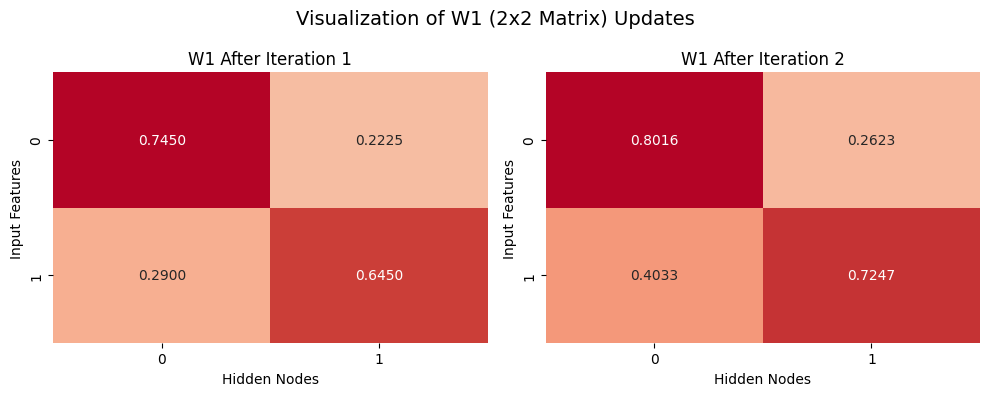

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

X = np.array([[1.0, 2.0]])
y = np.array([[3.0]])
lr = 0.1

W1 = np.array([[0.5, 0.1],
               [-0.2, 0.4]])
W2 = np.array([[1.0],
               [0.5]])

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

w1_history = []

print("Starting Training...\n")

for i in range(2):
    print(f"--- ITERATION {i+1} ---")

    Z1 = np.dot(X, W1)
    H1 = relu(Z1)
    y_pred = np.dot(H1, W2)

    loss = 0.5 * np.sum((y_pred - y)**2)
    print(f"Prediction: {y_pred[0][0]:.4f} | Loss: {loss:.4f}")

    dy_pred = y_pred - y
    dW2 = np.dot(H1.T, dy_pred)

    dH1 = np.dot(dy_pred, W2.T)
    dZ1 = dH1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)

    W1 = W1 - (lr * dW1)
    W2 = W2 - (lr * dW2)

    print("Updated 2x2 Weights (W1):")
    print(np.round(W1, 4), "\n")

    w1_history.append(W1.copy())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Visualization of W1 (2x2 Matrix) Updates", fontsize=14)

sns.heatmap(w1_history[0], annot=True, cmap="coolwarm", center=0, fmt=".4f", ax=axes[0], cbar=False)
axes[0].set_title("W1 After Iteration 1")
axes[0].set_xlabel("Hidden Nodes")
axes[0].set_ylabel("Input Features")

sns.heatmap(w1_history[1], annot=True, cmap="coolwarm", center=0, fmt=".4f", ax=axes[1], cbar=False)
axes[1].set_title("W1 After Iteration 2")
axes[1].set_xlabel("Hidden Nodes")
axes[1].set_ylabel("Input Features")

plt.tight_layout()
plt.show()

# Backpropagation using matrices: Try it yourself
The network architecture has expanded. We now have 2 input features, 3 hidden nodes, and 1 output node. Complete the forward pass, calculate the error, and use matrix transpositions to successfully backpropagate the error and update both weight matrices. Refer to the skeleton code

In [17]:
import numpy as np

# 1. THE SETUP (Do not change these)
# Input (1x2) and Target (1x1)
X = np.array([[2.0, 1.0]])
y = np.array([[4.0]])

# Learning Rate
lr = 0.05

# Initial Weights
# W1 is 2x3 (2 inputs connected to 3 hidden nodes)
W1 = np.array([[ 0.5, -0.1,  0.2],
               [ 0.1,  0.3, -0.4]])

# W2 is 3x1 (3 hidden nodes connected to 1 output node)
W2 = np.array([[ 1.0],
               [ 0.5],
               [-1.0]])

print("--- INITIAL WEIGHTS ---")
print("W1 (2x3):\n", W1)
print("W2 (3x1):\n", W2, "\n")

# Helper functions for ReLU
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# ==========================================
# STEP 1: THE FORWARD PASS
# ==========================================
# Calculate Z1 (Shape should be 1x3). Hint: use np.dot()
Z1 = np.dot(X, W1)

# Apply ReLU to get H1 (Shape will be 1x3)
H1 = relu(Z1)

# Calculate final prediction y_pred (Shape should be 1x1)
y_pred = np.dot(H1, W2)

print("--- FORWARD PASS ---")
print(f"Prediction: {y_pred[0][0]:.4f} (Target is {y[0][0]})\n")

# ==========================================
# STEP 2: THE LOSS
# ==========================================
# Calculate the raw error (Prediction - Target)
dy_pred = y_pred - y

# Calculate MSE Loss: 0.5 * sum of squared error
loss = 0.5 * np.sum(dy_pred**2)

print("--- LOSS CALCULATION ---")
print(f"Raw Error: {dy_pred[0][0]:.4f}")
print(f"MSE Loss: {loss:.4f}\n")

# ==========================================
# STEP 3: BACKPROPAGATION (THE GRADIENTS)
# ==========================================
# 1. Gradients for W2 (Shape must match W2: 3x1)
dW2 = np.dot(H1.T, dy_pred)

# 2. Error at the Hidden Layer (Shape must be 1x3)
dH1 = np.dot(dy_pred, W2.T)

# 3. Apply the ReLU derivative to the hidden error (Element-wise multiplication)
dZ1 = dH1 * relu_derivative(Z1)

# 4. Gradients for W1 (Shape must match W1: 2x3)
dW1 = np.dot(X.T, dZ1)

print("--- CALCULATED GRADIENTS ---")
print("dW1 (2x3):\n", dW1)
print("dW2 (3x1):\n", dW2, "\n")

# ==========================================
# STEP 4: GRADIENT DESCENT (WEIGHT UPDATE)
# ==========================================
# Update W1 and W2 using the learning rate (lr)
W1_new = W1 - lr * dW1
W2_new = W2 - lr * dW2

print("--- UPDATED WEIGHTS ---")
print("New W1:\n", np.round(W1_new, 4))
print("New W2:\n", np.round(W2_new, 4), "\n")

# ==========================================
# PROOF IT WORKED
# ==========================================
# Run a quick forward pass with the new weights to see if the prediction improved
new_Z1 = np.dot(X, W1_new)
new_H1 = relu(new_Z1)
new_prediction = np.dot(new_H1, W2_new)

print("--- FINAL RESULT ---")
print(f"Old Prediction: {y_pred[0][0]:.4f}")
print(f"New Prediction: {new_prediction[0][0]:.4f}")
print("If successful, the new prediction should be closer to 4.0!")

--- INITIAL WEIGHTS ---
W1 (2x3):
 [[ 0.5 -0.1  0.2]
 [ 0.1  0.3 -0.4]]
W2 (3x1):
 [[ 1. ]
 [ 0.5]
 [-1. ]] 

--- FORWARD PASS ---
Prediction: 1.1500 (Target is 4.0)

--- LOSS CALCULATION ---
Raw Error: -2.8500
MSE Loss: 4.0612

--- CALCULATED GRADIENTS ---
dW1 (2x3):
 [[-5.7   -2.85   0.   ]
 [-2.85  -1.425  0.   ]]
dW2 (3x1):
 [[-3.135]
 [-0.285]
 [ 0.   ]] 

--- UPDATED WEIGHTS ---
New W1:
 [[ 0.785   0.0425  0.2   ]
 [ 0.2425  0.3712 -0.4   ]]
New W2:
 [[ 1.1568]
 [ 0.5142]
 [-1.    ]] 

--- FINAL RESULT ---
Old Prediction: 1.1500
New Prediction: 2.3312
If successful, the new prediction should be closer to 4.0!
